In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler

# Part 1.2: Intronic vs Intergenic enhancers

### Seperating Intronic and Intergenic enhancers
1) defining promotors using TSS metadata from yoshida
2) defining Intergenic peaks using txStart/End
3) defining Intronic peaks through "Ausschlussverfahren" (as long as we are ignoring Exonic peaks)

In [6]:
#Making an "only-promotor" dataset and an "only-enhancer" dataset based on wheter TSS = NaN
only_promotor = ATAC_data_removed[ATAC_data_removed["TSS"].notna()].copy() 
only_enhancers = ATAC_data_removed[ATAC_data_removed["TSS"].isna()].copy()

only_enhancers.head()

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
2,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,2.36,0.10,...,0.87,0.54,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11
3,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.41,0.10,...,0.44,1.83,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11
4,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.41,0.10,...,0.44,0.10,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50
5,ImmGenATAC1219.peak_6,chr1,3399217,0.06,2.39,1.0,NaN,NaN,2.36,1.64,...,1.34,0.29,0.23,0.89,0.11,0.53,1.40,0.90,2.87,9.09
6,ImmGenATAC1219.peak_7,chr1,3400115,0.44,2.57,1.0,NaN,NaN,0.41,0.10,...,0.87,1.93,0.59,0.11,1.39,2.58,0.75,2.30,2.34,11.02


In [10]:
def is_inside_gene(row, refFlat):
    same_chrom_genes = refFlat[refFlat["chrom"] == row["chrom"]] 
    #only take those refFlat values where the chrom is the same as the chrom in the ATACseq row
    
    inside = same_chrom_genes[
        (same_chrom_genes["txStart"] <= row["Summit"]) &
        (same_chrom_genes["txEnd"] >= row["Summit"])
        ]

    return len(inside) > 0

# This function checks wheter there is ANY gene in the refFlat where the txStart is lower than the Summit and the txEnd is higher.
# is_inside_gene(ATAC_data_removed.iloc[row], refFlat)


##archive: row = ATAC_data_removed.iloc[i] and for range(len(only_enhancers))
##archive: row = only_enhancers.iloc[i] for a range like 50

list_of_results = []

for i in range(len(only_enhancers)):
    row = only_enhancers.iloc[i]
    list_of_results.append(is_inside_gene(row, refFlat))

# create new column
only_enhancers["inside gene"] = list_of_results

#ChatGPT: Creating Label
only_enhancers["OCR_location"] = only_enhancers["inside gene"].map({
    True: "intronic_or_gene_body",
    False: "intergenic"
})

only_enhancers.head()
#took over 50 min to load
#need to find way around here


,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th,inside gene,OCR_location
2,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,2.36,0.10,...,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11,False,intergenic
3,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.41,0.10,...,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11,False,intergenic
4,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.41,0.10,...,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50,True,intronic_or_gene_body
5,ImmGenATAC1219.peak_6,chr1,3399217,0.06,2.39,1.0,NaN,NaN,2.36,1.64,...,0.23,0.89,0.11,0.53,1.40,0.90,2.87,9.09,True,intronic_or_gene_body
6,ImmGenATAC1219.peak_7,chr1,3400115,0.44,2.57,1.0,NaN,NaN,0.41,0.10,...,0.59,0.11,1.39,2.58,0.75,2.30,2.34,11.02,True,intronic_or_gene_body


In [11]:
only_enhancers.to_csv('data/only_enhancers_intronic_labled', index=False)

# Part 2.4: Repressive vs. Active CREs

### 2.4.1: Datensätze und Packages vorbereiten

In [2]:
#General: Packages


import numpy as np
import pandas as pd
from ast import literal_eval    #str like code to code


import seaborn as sns  
import matplotlib.pyplot as plt


from sklearn.linear_model import Ridge, RidgeCV #choose best alpha w/ ridgeCV
from sklearn.preprocessing import StandardScaler #mean=0 sd=1
from sklearn.metrics import r2_score 
from sklearn.model_selection import cross_val_score, KFold

from sklearn.pipeline import make_pipeline 

In [38]:
#General: Datasets

#RNA
RNA_seq_path = Path('data') / 'mmc2.csv'
RNA_seq = pd.read_csv(RNA_seq_path)
RNAseq_reg = RNA_seq.copy()


annotation_cols = [
    "ImmGenATAC1219.peakID",
    "Summit",
    "chrom",
    "mm10.60way.phastCons_scores",
    "_-log10_bestPvalue",
    "Included.in.systematic.analysis",
    "TSS",
    "genes.within.100Kb"
]

#ATAC
ATAC_pfiltered_path = Path('data') / 'ATAC_pfiltered.csv'
ATAC_data = pd.read_csv(ATAC_pfiltered_path)

ATACseq_reg = ATAC_data[ATAC_data["TSS"].isnull()] #removing TSS

#RNA_TGD Cells
RNA_seq_gd_path = Path('data') / 'RNA_seq_gd_anot.csv'
RNA_seq_gd = pd.read_csv(RNA_seq_gd_path)

#ATAC_TGD Cells
ATAC_gd_path = Path('data') / 'ATAC_seq_gd_anot.csv'
ATAC_seq_gd_TSS = pd.read_csv(ATAC_gd_path)

ATACseq_gd_reg = ATAC_seq_gd_TSS[ATAC_seq_gd_TSS["TSS"].isnull()] #removing TSS


#Gene Annotations

cols = [
    "gene_name",
    "transcript_name",
    "chrom",
    "strand",
    "txStart",
    "txEnd",
    "cdsStart",
    "cdsEnd",
    "exonCount",
    "exonStarts",
    "exonEnds"
]

gene_annotations_path = Path('data') / 'Gene annotations.txt'

gene_annotations = pd.read_csv(gene_annotations_path, sep="\t", names=cols)



### 2.4.2: Regressionsmodelle - Funktioniert das Modell?

In [9]:
#erstes Modell - noTSS - all Cells

def r2_gen(gen_name):

    #Y_RNA
    RNA_seq_Gene = RNAseq_reg[RNAseq_reg["Unnamed: 0"] == gen_name]
    y = RNA_seq_Gene.drop("Unnamed: 0", axis=1, errors="ignore").T

    #X_ATAC
    ATAC_seq_Gene = ATACseq_reg[ATACseq_reg["genes.within.100Kb"].fillna("").str.contains(rf"\b{gen_name}\b")]
    peak_ids = ATACseq_reg["ImmGenATAC1219.peakID"].values  # ← vor .T
    X = ATAC_seq_Gene.drop(annotation_cols, axis=1, errors="ignore").T
    
    #Index angleichen
    common_cells = X.index.intersection(y.index)
    X = X.loc[common_cells]
    y = y.loc[common_cells]

    #Standardscale and choosing best alpha
    X_scaled = StandardScaler().fit_transform(X)
    ridge = RidgeCV(alphas=[10, 100, 1000, 10000, 100000], cv=KFold(5, shuffle=True, random_state=0))
    ridge.fit(X_scaled, y)

    r2 = ridge.score(X_scaled, y)
    best_alpha = ridge.alpha_

    # CV mit bestem alpha
    cv = cross_val_score(make_pipeline(StandardScaler(), Ridge(alpha=best_alpha)),
                         X, y,cv=KFold(5, shuffle=True, random_state=0),
                         scoring="r2").mean()
        
    return  r2, cv, ridge


r2_Il17f, cv, ridge_Il17f= r2_gen("Il17f")

In [11]:
#zweites Modell - noTSS - TGD Cells

def r2_gen_gd(gen_name):
    #Y_RNA
    RNA_seq_Gene = RNA_seq_gd[RNA_seq_gd["Unnamed: 0"] == gen_name]
    y = RNA_seq_Gene.drop("Unnamed: 0", axis=1, errors="ignore").T

    #X_ATAC
    ATAC_seq_Gene = ATACseq_gd_reg[ATACseq_gd_reg["genes.within.100Kb"].fillna("").str.contains(rf"\b{gen_name}\b")]
    peak_ids = ATACseq_gd_reg["ImmGenATAC1219.peakID"].values  # ← vor .T
    X = ATAC_seq_Gene.drop(annotation_cols, axis=1, errors="ignore").T
    
    #Index angleichen
    common_cells = X.index.intersection(y.index)
    X = X.loc[common_cells]
    y = y.loc[common_cells]

    #Standardscale and choosing best alpha
    X_scaled = StandardScaler().fit_transform(X)
    ridge = RidgeCV(alphas=[10, 100, 1000, 10000, 100000], cv=KFold(5, shuffle=True, random_state=0))
    ridge.fit(X_scaled, y)

    r2 = ridge.score(X_scaled, y)
    best_alpha = ridge.alpha_

    # CV mit bestem alpha
    cv = cross_val_score(
        make_pipeline(StandardScaler(), Ridge(alpha=best_alpha)),
        X, y,
        cv=KFold(5, shuffle=True, random_state=0),
        scoring="r2"
    ).mean()
        
    return  r2, cv, ridge


r2_Il17f, cv, ridge= r2_gen_gd("Il17f")


In [13]:
#vergleich beide modelle

compare = []

for gen_name in ["Il17f", "Rorc", "Sox13", "Gzma", "Eomes", "Actb"]:
    r2_all, cv_all,_ = r2_gen(gen_name)
    r2_gd, cv_gd, _ = r2_gen_gd(gen_name)


    compare.append({
        "Gene": gen_name,
        "R² (all)": round(r2_all, 3),
        "CV (all)": round(cv_all, 3),
        "R² (gd)": round(r2_gd, 3),
        "CV (gd)": round(cv_gd, 3),
    })

compare_df = pd.DataFrame(compare)
display(compare_df)

,Gene,R² (all),CV (all),R² (gd),CV (gd)
0,Il17f,0.046,-4.202,0.753,-36.095
1,Rorc,0.901,0.668,0.992,-8251.986
2,Sox13,0.445,-214.382,0.993,-22.483
3,Gzma,0.985,0.908,0.984,-7.616
4,Eomes,0.985,0.925,0.988,-37097.790
5,Actb,0.631,0.172,0.750,-1.313


Rorc, Gzma und Eomes zeigen hohe Gini-Scores in γδ-T-Zellen und können gleichzeitig durch die chromatin accessibility ihrer CREs über alle Immunzelltypen hinweg stabil vorhergesagt werden (hohes R², positives CV).#

Das Modell funktioniert besser wenn man all Cells ATAC benutzt

### 2.4.3: Activating vs. repressing CREs based on sign of reg. coef.

In [15]:
#build_gene_peak_dict(ATAC_seq)
#all peaks associated to a certain gene based on w/i 100kb

def build_gene_peak_dict(ATAC_seq):

    gene_to_peaks = {}
    ATAC_filtered = ATAC_seq[ATAC_seq["genes.within.100Kb"].notna()]

    for index, row in ATAC_filtered.iterrows():
        
        peak_ID = row["ImmGenATAC1219.peakID"]

        for gene in str(row["genes.within.100Kb"]).split(","):
            
            gene = gene.strip()

            if gene not in gene_to_peaks:
                gene_to_peaks[gene] = []
            
            gene_to_peaks[gene].append(peak_ID)

    return gene_to_peaks

gene_peak_dictionary = build_gene_peak_dict(ATACseq_reg)

In [24]:
#saving the dictionary

gene_peak_df = pd.DataFrame([(gene, peak)
     for gene, peaks in gene_peak_dictionary.items()
     for peak in peaks],columns=["gene", "peakID"])

gene_peak_df.to_csv('data/gene_peak_dictionary.csv', index=False) 

In [18]:
#r2_gen_TSS - ridge function w/ Promotor

ATACseq_reg_TSS = ATAC_data.copy()

def r2_gen_TSS(gen_name):

    #Y_RNA
    RNA_seq_Gene = RNAseq_reg[RNAseq_reg["Unnamed: 0"] == gen_name]
    y = RNA_seq_Gene.drop("Unnamed: 0", axis=1, errors="ignore").T

    #X_ATAC
    peak_ids = gene_peak_dictionary.get(gen_name, [])
    ATAC_seq_Gene = ATACseq_reg_TSS[ATACseq_reg_TSS["ImmGenATAC1219.peakID"].isin(peak_ids)]

    X = ATAC_seq_Gene.drop(annotation_cols, axis=1, errors="ignore").T
    
    #Index angleichen
    common_cells = X.index.intersection(y.index)
    X = X.loc[common_cells]
    y = y.loc[common_cells]

    #Standardscale and choosing best alpha
    X_scaled = StandardScaler().fit_transform(X)
    ridge = RidgeCV(alphas=[10, 100, 1000, 10000, 100000], cv=KFold(5, shuffle=True, random_state=0))
    ridge.fit(X_scaled, y)

    r2 = ridge.score(X_scaled, y)
    best_alpha = ridge.alpha_

    # CV mit bestem alpha
    cv = cross_val_score(
        make_pipeline(StandardScaler(), Ridge(alpha=best_alpha)),
        X, y,
        cv=KFold(5, shuffle=True, random_state=0),
        scoring="r2"
    ).mean()
        
    return  r2, cv, ridge

In [22]:
#Coefficient Dataframe

def coef_gen(gen_name):
    r2, cv, ridge = r2_gen_TSS(gen_name)

    peak_ids = gene_peak_dictionary.get(gen_name, [])
    coef_df = pd.DataFrame({"peakID": peak_ids, "coefficient": ridge.coef_})

    #eine Spalte soll direkt Vorzeichen interpretieren
    coef_df["sign"] = coef_df["coefficient"].apply(lambda x: "+" if x > 0 else "-")

    # Effektstärke
    coef_df["abs_coefficient"] = coef_df["coefficient"].abs().round(1)

    # zuerst repressing/activating, dann nach Stärke
    coef_df = coef_df.sort_values(by=["abs_coefficient"], ascending=[False])

    return coef_df, r2, cv, peak_ids

coef_Gzma, r2, cv, peak_ids = coef_gen("Gzma")
coef_Gzma

,peakID,coefficient,sign,abs_coefficient
22,ImmGenATAC1219.peak_142098,718.268051,+,718.3
17,ImmGenATAC1219.peak_142093,487.313700,+,487.3
18,ImmGenATAC1219.peak_142094,-419.764119,-,419.8
48,ImmGenATAC1219.peak_142129,410.201623,+,410.2
36,ImmGenATAC1219.peak_142114,402.325683,+,402.3
...,...,...,...,...
3,ImmGenATAC1219.peak_142071,9.154861,+,9.2
11,ImmGenATAC1219.peak_142082,-7.146110,-,7.1
57,ImmGenATAC1219.peak_142143,6.824026,+,6.8
58,ImmGenATAC1219.peak_142144,-3.667355,-,3.7


### (Runtime) 2.4.5: Creating a dataframe w/ just repressive regulated genes

In [ ]:
#function that checks which Genes are regulated primarely by repressive CREs


def find_repressive_genes(RNAseq, rep_threshold = 50, topk_threshold = 10):

    results = []

    genes = RNAseq["Unnamed: 0"].unique()

    for gene in genes:
        try:
            coef_df, r2, cv = coef_gen(gene)

            #Repressionsanteil
            total_effect = coef_df["abs_coefficient"].sum()

            if total_effect == 0:
                continue
            
            repression_percent = (coef_df.loc[coef_df["coefficient"] < 0,"abs_coefficient"].sum()
                                  /total_effect) * 100
            
            #Ist unter den Top-k mindestens ein Repressor?
            topk_has_repressor = (coef_df.sort_values("abs_coefficient", ascending=False).head(topk_threshold)["coefficient"] < 0).any()

            #Criterions erfüllt?
            if (repression_percent >= rep_threshold and topk_has_repressor):
                
                strongest_repressor = (coef_df[coef_df["coefficient"] < 0].sort_values("abs_coefficient", ascending=False).iloc[0])

                strongest_activator = (coef_df[coef_df["coefficient"] > 0].sort_values("abs_coefficient", ascending=False).iloc[0])

                results.append({
                    "gene": gene,
                    "repression_percent": round(repression_percent,1),

                    "strongest_repressor_peakID": strongest_repressor["peakID"],
                    "strongest_repressor_coef": strongest_repressor["coefficient"],

                    "strongest_activator_peakID": strongest_activator["peakID"],
                    "strongest_activator_coef": strongest_activator["coefficient"],

                    "r2": round(r2, 2),
                    "cv": round(cv, 2),

                    "cv_category":
                        "Sehr Gut" if cv > 0.85 else
                        "Okay" if cv > 0.59 else
                        "wenigstens im positiven" if cv > 0 else
                        "negativ :(",
                })
                        
        except Exception:
            continue
        
    return pd.DataFrame(results)


givamialista = find_repressive_genes(RNA_seq, rep_threshold = 50, topk_threshold = 10)
givamialista.to_csv("data/repressive_regulated_genes.csv",index=False)

In [ ]:
#dictionary with all genes listed and their respective peaks within 100kb
gene_peak_dictionary


#dictionary with all genes listed and the abs_coef of all their peaks

gene_coef_dictionary = {}

for gen_name in gene_peak_dictionary.keys():
    try:
        coef_df, r2, cv, peak_ids = coef_gen(gen_name)
        
        peak_coef_dict = dict(zip(coef_df["peakID"],coef_df["coefficient"]))

        gene_coef_dictionary[gen_name] = {
                "cv": cv,
                "r2": r2,
                "coefs": peak_coef_dict}
    
    except Exception as e:
        gene_coef_dictionary[gen_name] = {
                "cv": None,
                "r2": None,
                "coefs": {},
                "error": str(e)
            }

gene_coef_df = pd.DataFrame.from_dict(
    gene_coef_dictionary,
    orient="index"
).reset_index()

gene_coef_df = gene_coef_df.rename(
    columns={"index": "gene"}
)

gene_coef_df.to_csv("data/gene_coef_dictionary.csv", index=False)

### 2.4.5: Analyzing the repressive CRE in more detail

In [ ]:
#extracting coef_dictionary

gene_coef_dictionary_path = Path('data') / 'gene_coef_dictionary.csv'
gene_coef_dictionary = pd.read_csv(gene_coef_dictionary_path)
gene_coef_dictionary = gene_coef_dictionary.dropna(subset=["cv"])

genes_OkayCV = gene_coef_dictionary[gene_coef_dictionary["cv"] >= 0.35]


#dataframe (gene|rep.%|rep. or act|strongest rep.|strongest act.)

genes_by_rep_perc = []

for gene in genes_OkayCV["gene"]:
    
    row = genes_OkayCV.loc[genes_OkayCV["gene"] == gene].iloc[0]
    coef_dict = literal_eval(row["coefs"])

    coef_theframe = pd.DataFrame({
    "peak_id": coef_dict.keys(),
    "coefficient": coef_dict.values()})

    coef_theframe["abs_coefficient"] = coef_theframe["coefficient"].abs()

    
    repression_percent = (coef_theframe.loc[coef_theframe["coefficient"] < 0,"abs_coefficient"].sum() /coef_theframe["abs_coefficient"].sum()) * 100

    label = "repressive" if repression_percent > 50 else "active"

    genes_by_rep_perc.append({
        "gene": gene,
        "rep_perc": repression_percent,
        "rep_or_act": label,
        "min_coef": coef_theframe["coefficient"].min(),
        "max_coef": coef_theframe["coefficient"].max()
    })

genes_by_rep_perc = pd.DataFrame(genes_by_rep_perc)
genes_by_rep_perc    



,gene,rep_perc,rep_or_act,min_coef,max_coef
0,Sgk3,32.791131,active,-16.414478,17.242355
1,Eya1,25.035020,active,-3.429320,9.499988
2,Paqr8,26.939168,active,-2.090688,4.896036
3,Khdc1a,22.533038,active,-0.706652,1.313319
4,Khdc1b,28.905655,active,-2.461844,3.484913
...,...,...,...,...,...
3197,Tlr8,29.015411,active,-6.532568,17.432431
3198,Tlr7,34.338509,active,-10.736424,23.350705
3199,Prps2,29.971340,active,-13.835208,49.690647
3200,Arhgap6,27.554101,active,-4.497519,8.846441


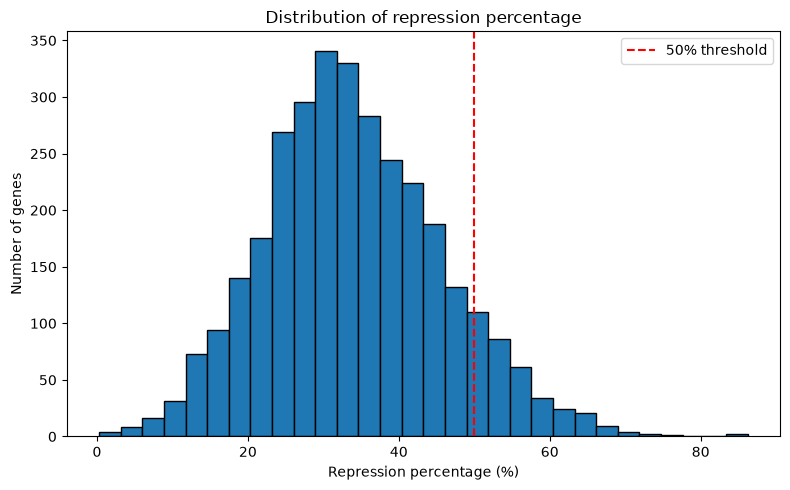

In [70]:
plt.figure(figsize=(8,5))
plt.hist(genes_by_rep_perc["rep_perc"], bins=30, edgecolor="black")

plt.axvline(50, color="red", linestyle="--", label="50% threshold")

plt.xlabel("Repression percentage (%)")
plt.ylabel("Number of genes")
plt.title("Distribution of repression percentage")
plt.legend()

plt.tight_layout()
plt.show()

Most Genes are not primarely repressive regulated.

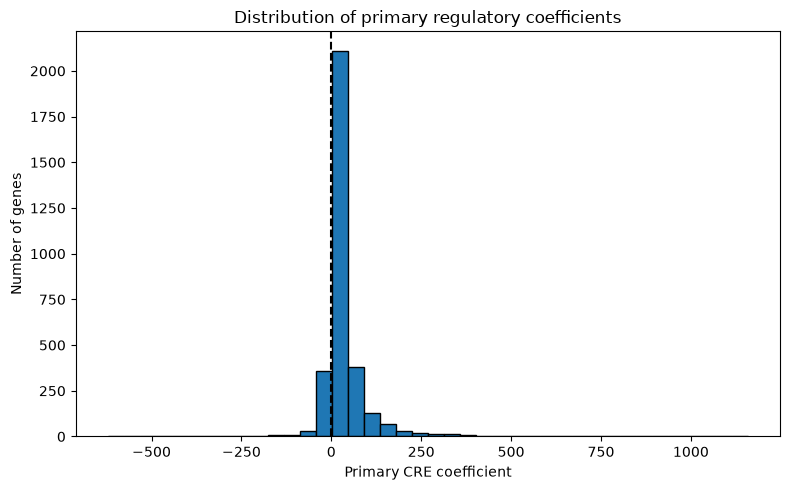

In [30]:
genes_by_rep_perc["primary_coef"] = np.where(
    genes_by_rep_perc["rep_or_act"] == "active",
    genes_by_rep_perc["max_coef"],
    genes_by_rep_perc["min_coef"]
)

plt.figure(figsize=(8,5))

plt.hist(genes_by_rep_perc["primary_coef"], bins=40, edgecolor="black")

plt.axvline(0, color="black", linestyle="--")

plt.xlabel("Primary CRE coefficient")
plt.ylabel("Number of genes")
plt.title("Distribution of primary regulatory coefficients")

plt.tight_layout()
plt.show()

### 2.4.6: Where are repressing CREs located relative to activating CREs?

In [ ]:
#list all peaks
rows = []

for _, row in genes_OkayCV.iterrows():

    gene = row["gene"]
    coef_dict = eval(row["coefs"])

    for peak_id, coef in coef_dict.items():

        rows.append({
            "gene": gene,
            "peakID": peak_id,
            "coef": coef,
            "sign": "activating" if coef > 0 else "repressing"
        })

peak_gene_pairs = pd.DataFrame(rows)

In [ ]:
#find summit of every peak

peak_gene_pairs = peak_gene_pairs.merge(
    ATAC_data[["ImmGenATAC1219.peakID", "Summit"]],
    left_on="peakID",
    right_on="ImmGenATAC1219.peakID",
    how="left"
).drop(columns="ImmGenATAC1219.peakID")

display(peak_gene_pairs)

,gene,peakID,coef,sign,Summit
0,Sgk3,ImmGenATAC1219.peak_605,17.242355,activating,9813129
1,Sgk3,ImmGenATAC1219.peak_660,-16.414478,repressing,9944186
2,Sgk3,ImmGenATAC1219.peak_604,14.587984,activating,9810817
3,Sgk3,ImmGenATAC1219.peak_582,14.341511,activating,9769742
4,Sgk3,ImmGenATAC1219.peak_601,13.692282,activating,9806129
...,...,...,...,...,...
215942,Tmlhe,ImmGenATAC1219.peak_512480,-0.921283,repressing,161388
215943,Tmlhe,ImmGenATAC1219.peak_512486,0.351447,activating,259184
215944,Tmlhe,ImmGenATAC1219.peak_512474,0.333160,activating,128427
215945,Tmlhe,ImmGenATAC1219.peak_512475,-0.186884,repressing,139034


In [41]:
#calculate TSS

gene_annotations["TSS"] = gene_annotations.apply(
    lambda row: row["txStart"] if row["strand"] == "+" else row["txEnd"],
    axis=1
)

#add calculate to df
peak_gene_pairs = peak_gene_pairs.merge(
    gene_annotations[["gene_name", "TSS"]].drop_duplicates("gene_name"),
    left_on="gene",
    right_on="gene_name",
    how="left"
).drop(columns="gene_name")

peak_gene_pairs["distance_to_TSS"] = peak_gene_pairs["Summit"] - peak_gene_pairs["TSS"]

display(peak_gene_pairs)

,gene,peakID,coef,sign,Summit,TSS_x,TSS_y,TSS,distance_to_TSS
0,Sgk3,ImmGenATAC1219.peak_605,17.242355,activating,9813129,9798129.0,9798129.0,9798129.0,15000.0
1,Sgk3,ImmGenATAC1219.peak_660,-16.414478,repressing,9944186,9798129.0,9798129.0,9798129.0,146057.0
2,Sgk3,ImmGenATAC1219.peak_604,14.587984,activating,9810817,9798129.0,9798129.0,9798129.0,12688.0
3,Sgk3,ImmGenATAC1219.peak_582,14.341511,activating,9769742,9798129.0,9798129.0,9798129.0,-28387.0
4,Sgk3,ImmGenATAC1219.peak_601,13.692282,activating,9806129,9798129.0,9798129.0,9798129.0,8000.0
...,...,...,...,...,...,...,...,...,...
215942,Tmlhe,ImmGenATAC1219.peak_512480,-0.921283,repressing,161388,159644.0,159644.0,159644.0,1744.0
215943,Tmlhe,ImmGenATAC1219.peak_512486,0.351447,activating,259184,159644.0,159644.0,159644.0,99540.0
215944,Tmlhe,ImmGenATAC1219.peak_512474,0.333160,activating,128427,159644.0,159644.0,159644.0,-31217.0
215945,Tmlhe,ImmGenATAC1219.peak_512475,-0.186884,repressing,139034,159644.0,159644.0,159644.0,-20610.0


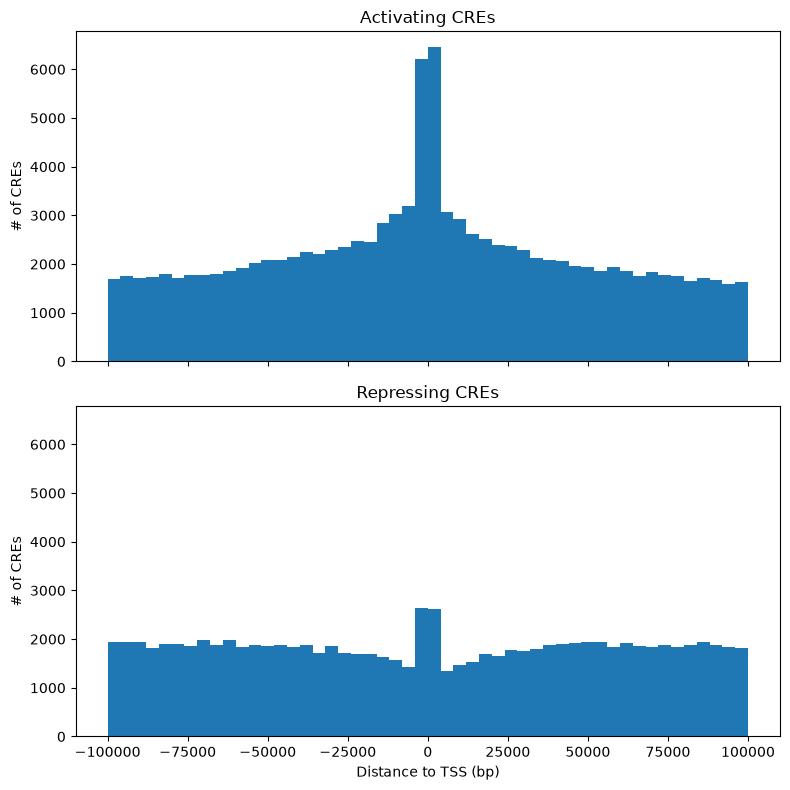

In [48]:
plot_df = peak_gene_pairs[
    peak_gene_pairs["distance_to_TSS"].abs() <= 100000
]

plot_df = peak_gene_pairs[
    peak_gene_pairs["distance_to_TSS"].abs() <= 100000
]

fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True, sharey=True)

# Activating
axes[0].hist(
    plot_df.loc[plot_df["sign"] == "activating", "distance_to_TSS"],
    bins=50
)
axes[0].set_title("Activating CREs")
axes[0].set_ylabel("# of CREs")

# Repressing
axes[1].hist(
    plot_df.loc[plot_df["sign"] == "repressing", "distance_to_TSS"],
    bins=50
)
axes[1].set_title("Repressing CREs")
axes[1].set_xlabel("Distance to TSS (bp)")
axes[1].set_ylabel("# of CREs")

plt.tight_layout()
plt.show()